<a href="https://colab.research.google.com/github/cdiegor/Metaheuristicas/blob/main/Matheuristics_UFL_2D_animated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Matheuristics em UFL 2D — Versão com Animações

**Novidade:** animações quadro-a-quadro mostrando a **evolução** das três matheurísticas:
- **Local Branching (LB)** com raio `k` variando;
- **Fix-and-Optimize (F&O)** com blocos liberados ao longo do tempo;
- **RINS-like** exibindo o conjunto de variáveis fixadas por acordo.

Cada animação salva um **GIF** em `/mnt/data/`, além de aparecer inline quando você executar a célula.


In [ ]:
!pip install ortools

In [ ]:

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Tuple
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from ortools.sat.python import cp_model
import random, copy

random.seed(42); np.random.seed(42)


In [ ]:

@dataclass
class UFLInstance:
    clients: np.ndarray
    facs: np.ndarray
    open_cost: np.ndarray
    dist: np.ndarray
    scale: int

def gerar_instancia(m=20, n=7, lado=100.0, seed=2025, escala=1000, custo_abertura=(18.0, 42.0)) -> UFLInstance:
    rng = np.random.default_rng(seed)
    clients = rng.uniform(0, lado, size=(m,2))
    facs = rng.uniform(0, lado, size=(n,2))
    open_cost = rng.uniform(custo_abertura[0], custo_abertura[1], size=n)
    d = np.linalg.norm(clients[:,None,:] - facs[None,:,:], axis=2)
    dist_scaled = np.rint(d * escala).astype(int)
    oc_scaled   = (open_cost * escala).astype(int)
    return UFLInstance(clients=clients, facs=facs, open_cost=oc_scaled, dist=dist_scaled, scale=escala)


In [ ]:

@dataclass
class UFLSolution:
    y: np.ndarray
    x: np.ndarray
    obj: float

def objetivo(inst: UFLInstance, y: np.ndarray, x: np.ndarray) -> float:
    return ((inst.dist * x).sum() + (inst.open_cost * y).sum()) / inst.scale

def plot_ufl(inst: UFLInstance, y_open: np.ndarray, assign: np.ndarray, titulo:str=""):
    m, n = inst.clients.shape[0], inst.facs.shape[0]
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(inst.clients[:,0], inst.clients[:,1], c='0.5', s=20, label='Clientes')
    for j in range(n):
        if y_open[j] > 0.5:
            ax.scatter(inst.facs[j,0], inst.facs[j,1], marker='s', s=80, edgecolors='k', label='_nolegend_')
        else:
            ax.scatter(inst.facs[j,0], inst.facs[j,1], marker='s', facecolors='none', edgecolors='k', s=80, label='_nolegend_')
    for i in range(m):
        j = np.argmax(assign[i])
        if assign[i,j] > 0.5 and y_open[j] > 0.5:
            ax.plot([inst.clients[i,0], inst.facs[j,0]], [inst.clients[i,1], inst.facs[j,1]], 'k-', lw=0.8, alpha=0.6)
    ax.set_title(titulo); ax.set_aspect('equal', 'box')
    ax.legend(loc='upper right'); plt.show()


In [ ]:

def solve_ufl(inst: UFLInstance, time_limit: float = 1.2,
              fix_y: Dict[int,int] | None = None,
              lb_hamming_center: np.ndarray | None = None, lb_k: int | None = None) -> UFLSolution | None:
    m, n = inst.clients.shape[0], inst.facs.shape[0]
    model = cp_model.CpModel()

    y = [model.NewBoolVar(f'y[{j}]') for j in range(n)]
    x = [[model.NewBoolVar(f'x[{i},{j}]') for j in range(n)] for i in range(m)]

    for i in range(m):
        model.Add(sum(x[i][j] for j in range(n)) == 1)
    for i in range(m):
        for j in range(n):
            model.Add(x[i][j] <= y[j])

    if fix_y:
        for j,v in fix_y.items():
            if v == 1:
                model.Add(y[j] == 1)
            elif v == 0:
                model.Add(y[j] == 0)

    if lb_hamming_center is not None and lb_k is not None:
        z = [model.NewBoolVar(f'diff[{j}]') for j in range(n)]
        for j in range(n):
            if lb_hamming_center[j] == 0:
                model.Add(z[j] == y[j])
            else:
                model.Add(z[j] + y[j] == 1)
        model.Add(sum(z) <= lb_k)

    terms = []
    for i in range(m):
        for j in range(n):
            terms.append(int(inst.dist[i,j]) * x[i][j])
    for j in range(n):
        terms.append(int(inst.open_cost[j]) * y[j])
    model.Minimize(sum(terms))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = float(time_limit)
    solver.parameters.num_search_workers = 8

    status = solver.Solve(model)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    y_sol = np.array([int(solver.Value(y[j])) for j in range(n)])
    x_sol = np.zeros((m,n), dtype=int)
    for i in range(m):
        for j in range(n):
            x_sol[i,j] = int(solver.Value(x[i][j]))
    obj = solver.ObjectiveValue() / inst.scale
    return UFLSolution(y_sol, x_sol, obj)


In [ ]:

def incumbente_guloso(inst: UFLInstance, abrir_k: int | None = None) -> UFLSolution:
    m, n = inst.clients.shape[0], inst.facs.shape[0]
    atr = np.zeros(n)
    for j in range(n):
        atr[j] = -np.sum(np.sort(inst.dist[:,j])[:max(1, m//n)])
    sc = atr / (inst.open_cost + 1e-6)
    k = abrir_k if abrir_k is not None else max(1, n//2)
    idx = np.argsort(-sc)[:k]
    y = np.zeros(n, dtype=int); y[idx] = 1
    x = np.zeros((m,n), dtype=int)
    for i in range(m):
        abertos = np.where(y==1)[0]
        jbest = abertos[np.argmin(inst.dist[i,abertos])]
        x[i,jbest] = 1
    obj = objetivo(inst, y, x)
    return UFLSolution(y, x, obj)


### Controladores com *frames*

In [ ]:

def lb_com_frames(inst: UFLInstance, xbar: UFLSolution, k0: int = 1, passes: int = 6, tl_sub: float = 1.0):
    frames = []
    best = copy.deepcopy(xbar); k = k0
    frames.append((best.y.copy(), best.x.copy(), f"LB start | k={k} | obj={best.obj:.2f}"))
    for it in range(passes):
        cand = solve_ufl(inst, time_limit=tl_sub, lb_hamming_center=best.y, lb_k=k)
        if cand and cand.obj < best.obj - 1e-9:
            best = cand
            frames.append((best.y.copy(), best.x.copy(), f"LB improve | k={k} | obj={best.obj:.2f}"))
            k = max(1, k-1)
        else:
            k = min(inst.facs.shape[0], k+1)
            frames.append((best.y.copy(), best.x.copy(), f"LB no-improve | k→{k} | obj={best.obj:.2f}"))
    return best, frames

def fo_com_frames(inst: UFLInstance, xbar: UFLSolution, bloco_tam: int = 2, passes: int = 3, tl_sub: float = 1.0):
    frames = []
    n = inst.facs.shape[0]
    ordem = list(range(n))
    best = copy.deepcopy(xbar)
    frames.append((best.y.copy(), best.x.copy(), f"F&O start | obj={best.obj:.2f}"))
    for p in range(passes):
        random.shuffle(ordem)
        for s in range(0, n, bloco_tam):
            bloco = ordem[s:s+bloco_tam]
            fix = {j:int(best.y[j]) for j in range(n) if j not in bloco}
            cand = solve_ufl(inst, time_limit=tl_sub, fix_y=fix)
            if cand and cand.obj < best.obj - 1e-9:
                best = cand
                frames.append((best.y.copy(), best.x.copy(), f"F&O pass {p+1} blk {bloco} | obj={best.obj:.2f}"))
            else:
                frames.append((best.y.copy(), best.x.copy(), f"F&O pass {p+1} blk {bloco} | (no-improve) obj={best.obj:.2f}"))
    return best, frames

def rins_com_frames(inst: UFLInstance, xbar: UFLSolution, tl_guide: float = 0.6, tl_sub: float = 1.0):
    frames = []
    best = copy.deepcopy(xbar)
    frames.append((best.y.copy(), best.x.copy(), f"RINS start | obj={best.obj:.2f}"))
    guide = solve_ufl(inst, time_limit=tl_guide)
    guide = guide if guide else best
    fix = {}
    for j in range(inst.facs.shape[0]):
        if int(best.y[j]) == int(guide.y[j]):
            fix[j] = int(best.y[j])
    cand = solve_ufl(inst, time_limit=tl_sub, fix_y=fix)
    if cand and cand.obj < best.obj - 1e-9:
        best = cand
        frames.append((best.y.copy(), best.x.copy(), f"RINS improve | fix={len(fix)} | obj={best.obj:.2f}"))
    else:
        frames.append((best.y.copy(), best.x.copy(), f"RINS no-improve | fix={len(fix)} | obj={best.obj:.2f}"))
    return best, frames


In [ ]:

def animar_frames(inst: UFLInstance, frames: List[Tuple[np.ndarray, np.ndarray, str]], save_path: str | None = None, interval_ms: int = 700):
    m, n = inst.clients.shape[0], inst.facs.shape[0]
    fig, ax = plt.subplots(figsize=(6,6))
    clients_plot = ax.scatter(inst.clients[:,0], inst.clients[:,1], c='0.5', s=20, label='Clientes')
    facs_on  = ax.scatter([], [], marker='s', s=80, edgecolors='k', label='Aberta')
    facs_off = ax.scatter([], [], marker='s', facecolors='none', edgecolors='k', s=80, label='Fechada')
    linhas = []

    ax.set_aspect('equal','box')
    ax.legend(loc='upper right')

    def desenhar_frame(frame_idx):
        nonlocal linhas
        for ln in linhas:
            ln.remove()
        linhas = []
        y, x, titulo = frames[frame_idx]
        coords_on  = inst.facs[y.astype(bool)]
        coords_off = inst.facs[~y.astype(bool)]
        facs_on.set_offsets(coords_on if coords_on.size else np.empty((0,2)))
        facs_off.set_offsets(coords_off if coords_off.size else np.empty((0,2)))
        for i in range(m):
            j = np.argmax(x[i])
            if x[i,j] > 0.5 and y[j] > 0.5:
                ln, = ax.plot([inst.clients[i,0], inst.facs[j,0]], [inst.clients[i,1], inst.facs[j,1]], 'k-', lw=0.8, alpha=0.6)
                linhas.append(ln)
        ax.set_title(titulo)
        ax.set_xlim(inst.clients[:,0].min()-5, inst.clients[:,0].max()+5)
        ax.set_ylim(inst.clients[:,1].min()-5, inst.clients[:,1].max()+5)
        return [facs_on, facs_off] + linhas

    anim = FuncAnimation(fig, desenhar_frame, frames=len(frames), interval=interval_ms, blit=False)
    plt.close(fig)
    if save_path:
        try:
            anim.save(save_path, writer=PillowWriter(fps=max(1, int(1000/interval_ms))))
        except Exception as e:
            print("Aviso ao salvar GIF:", e)
    return anim


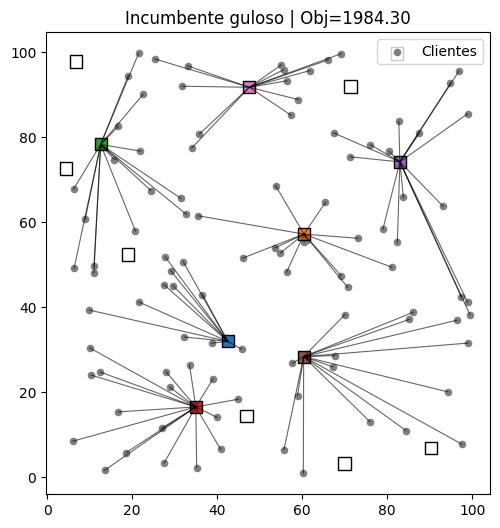

Resumo objetivos (menor é melhor):
 - Incumbente: 1984.30
 - LB: 1820.69
 - F&O: 1719.18
 - RINS-like: 1710.36
GIFs salvos em: ufl_lb.gif, ufl_fo.gif, ufl_rins.gif


In [17]:

# Demonstração + GIFs
inst = gerar_instancia(m=100, n=15)
inc = incumbente_guloso(inst, abrir_k=inst.facs.shape[0]//2)
plot_ufl(inst, inc.y, inc.x, titulo=f"Incumbente guloso | Obj={inc.obj:.2f}")

lb_sol, lb_frames = lb_com_frames(inst, inc, k0=1, passes=1, tl_sub=1.0)
anim_lb = animar_frames(inst, lb_frames, save_path='ufl_lb.gif', interval_ms=650)

fo_sol, fo_frames = fo_com_frames(inst, inc, bloco_tam=2, passes=1, tl_sub=1.0)
anim_fo = animar_frames(inst, fo_frames, save_path='ufl_fo.gif', interval_ms=650)

rins_sol, rins_frames = rins_com_frames(inst, inc, tl_guide=0.6, tl_sub=1.0)
anim_rins = animar_frames(inst, rins_frames, save_path='ufl_rins.gif', interval_ms=650)

print(f"Resumo objetivos (menor é melhor):\n - Incumbente: {inc.obj:.2f}\n - LB: {lb_sol.obj:.2f}\n - F&O: {fo_sol.obj:.2f}\n - RINS-like: {rins_sol.obj:.2f}")
print('GIFs salvos em: ufl_lb.gif, ufl_fo.gif, ufl_rins.gif')


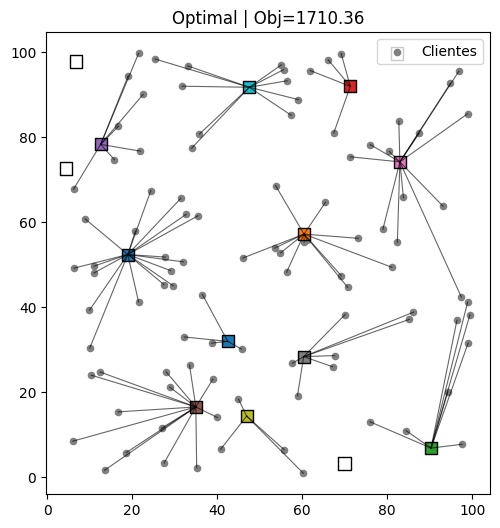

In [18]:
optimal = solve_ufl(inst, time_limit=60.0)
plot_ufl(inst,optimal.y, optimal.x, titulo=f"Optimal | Obj={optimal.obj:.2f}")